In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [91]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"
df = pd.read_csv(url)

print("Columns:", df.columns.tolist())
print(df.head())

Columns: ['Date', 'AAPL.Open', 'AAPL.High', 'AAPL.Low', 'AAPL.Close', 'AAPL.Volume', 'AAPL.Adjusted', 'dn', 'mavg', 'up', 'direction']
         Date   AAPL.Open   AAPL.High    AAPL.Low  AAPL.Close  AAPL.Volume  \
0  2015-02-17  127.489998  128.880005  126.919998  127.830002     63152400   
1  2015-02-18  127.629997  128.779999  127.449997  128.720001     44891700   
2  2015-02-19  128.479996  129.029999  128.330002  128.449997     37362400   
3  2015-02-20  128.619995  129.500000  128.050003  129.500000     48948400   
4  2015-02-23  130.020004  133.000000  129.660004  133.000000     70974100   

   AAPL.Adjusted          dn        mavg          up   direction  
0     122.905254  106.741052  117.927667  129.114281  Increasing  
1     123.760965  107.842423  118.940333  130.038244  Increasing  
2     123.501363  108.894245  119.889167  130.884089  Decreasing  
3     124.510914  109.785449  120.763500  131.741551  Increasing  
4     127.876074  110.372516  121.720167  133.067817  Increas

In [80]:
df = df[['Date', 'AAPL.Close']].rename(columns={'AAPL.Close': 'Close'})
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.sort_index()


In [81]:
print(f"\n Apple Stock loaded: {len(df)} days")
print(f"   From: {df.index.min().date()} → {df.index.max().date()}")
print(f"   Price: min=${df['Close'].min():.2f} | max=${df['Close'].max():.2f}")


 Apple Stock loaded: 506 days
   From: 2015-02-17 → 2017-02-16
   Price: min=$90.34 | max=$135.51


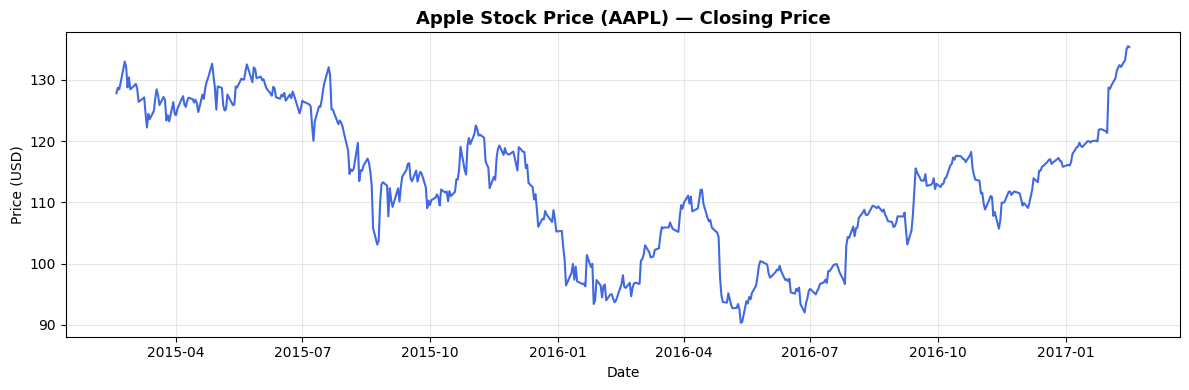

In [82]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Close'], color='royalblue', linewidth=1.5)
plt.title('Apple Stock Price (AAPL) — Closing Price', fontsize=13, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('apple_raw.png', dpi=150)
plt.show()


In [83]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['Close']])

In [84]:
TIME_STEPS = 30

def make_sequences(data, steps):
    X, y = [], []
    for i in range(len(data) - steps):
        X.append(data[i:i+steps])
        y.append(data[i+steps])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled, TIME_STEPS)
print(f"\nSequences: X={X.shape}, y={y.shape}")


Sequences: X=(476, 30, 1), y=(476, 1)


In [85]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 380 | Test: 96


In [86]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIME_STEPS, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0049 - mae: 0.0529 - val_loss: 0.0033 - val_mae: 0.0370
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0053 - mae: 0.0546 - val_loss: 0.0027 - val_mae: 0.0333
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0040 - mae: 0.0490 - val_loss: 0.0027 - val_mae: 0.0333
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0048 - mae: 0.0518 - val_loss: 0.0029 - val_mae: 0.0344
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0053 - mae: 0.0564 - val_loss: 0.0026 - val_mae: 0.0329
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0046 - mae: 0.0519 - val_loss: 0.0028 - val_mae: 0.0330
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0045 - mae: 0.0499 - val_loss: 0.0031 - val_mae: 0.0352
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0051 - mae: 0.0551 - val_loss: 0.0025 - val_mae: 0.0328
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.005

In [89]:
y_pred = scaler.inverse_transform(model.predict(X_test))
y_real = scaler.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_real, y_pred))
mae  = mean_absolute_error(y_real, y_pred)
mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

print(f"\n{'='*40}")
print(f"  RMSE : ${rmse:.2f}")
print(f"  MAE  : ${mae:.2f}")
print(f"  MAPE : {mape:.2f}%")
print(f"{'='*40}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 

  RMSE : $1.64
  MAE  : $1.23
  MAPE : 1.04%


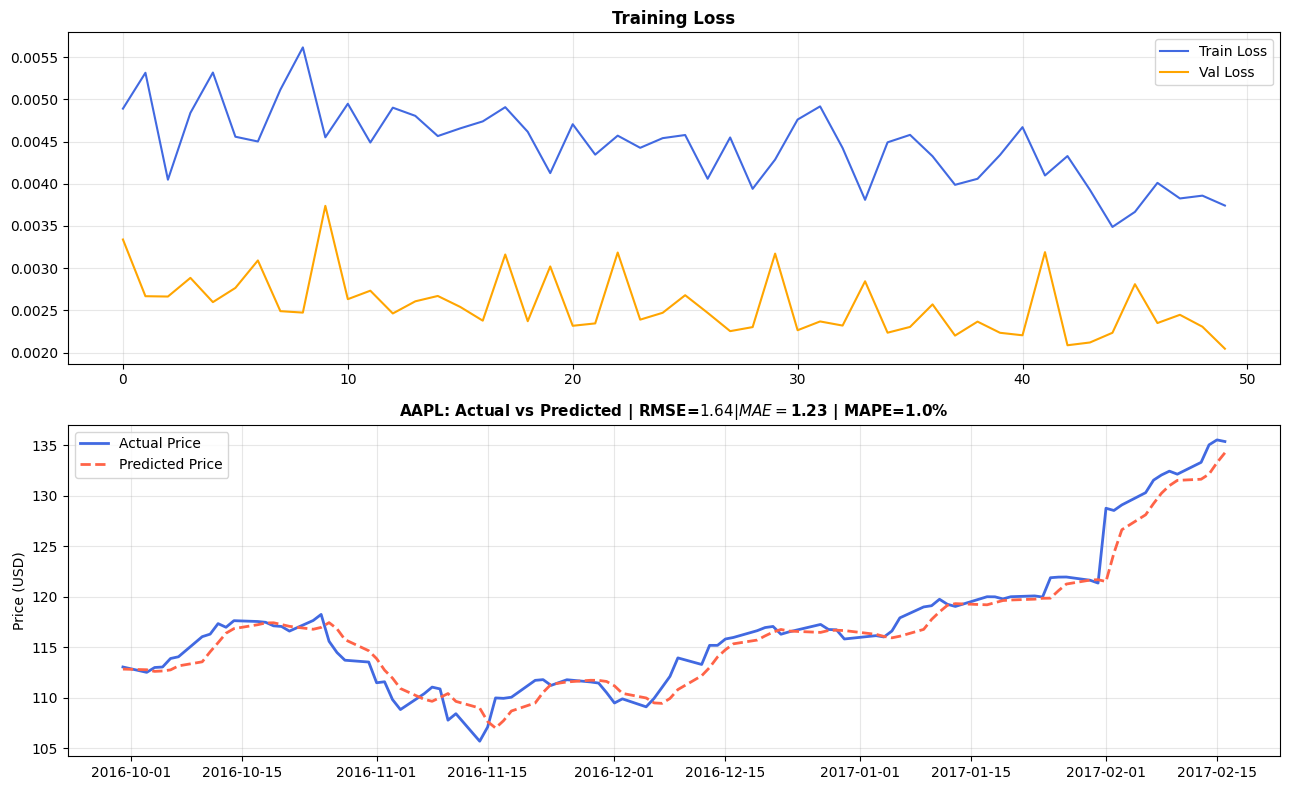

In [90]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='royalblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Predictions
test_dates = df.index[split + TIME_STEPS:]
axes[1].plot(test_dates, y_real, label='Actual Price',    color='royalblue', linewidth=2)
axes[1].plot(test_dates, y_pred, label='Predicted Price', color='tomato',
             linestyle='--', linewidth=2)
axes[1].set_title(f'AAPL: Actual vs Predicted | RMSE=${rmse:.2f} | MAE=${mae:.2f} | MAPE={mape:.1f}%',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Price (USD)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_apple.png', dpi=150)
plt.show()